# Model Evaluations — LSTM (Primary) vs DNN (Secondary)

**In-depth, head-to-head comparison** of the two deep models trained in `modelx.ipynb` on the
class-enriched `data1.csv` (>= 31.9% dementia positives). Both models share the identical
protocol — same stratified 80/20 split (`random_state=42`), same feature pipeline, same GPU
training machinery, same early stopping — so their hold-out predictions are **paired** and
directly comparable with paired statistical tests.

**Inputs** (exported by `modelx.ipynb`, nothing is retrained here):
`outputs/benchmark/{lstm,dnn}_metrics.json` and `..._holdout_predictions.csv`; each model also
ships a deployable checkpoint with MD5 checksum in `outputs/checkpoints/`.

**What is compared:** headline metrics, training/convergence behaviour, discrimination
(paired DeLong + bootstrap CIs), threshold behaviour and confusion structure (McNemar),
calibration (slope/intercept/ECE, raw vs isotonic), net reclassification (NRI/IDI),
decision-curve analysis, subgroup stability, capacity/efficiency, tuning robustness — closing
with a verdict and deployment recommendations.

Figures share the project's visual identity: **Raspberry `#C2185B`** for the LSTM (primary),
**Teal `#00838F`** for the DNN (secondary), on a **Pale Sky `#E0F2FE`** background.

In [1]:
# --- Inputs: the two models' benchmark artifacts (same hold-out, same seed) ------------
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats as st

from sklearn.calibration import calibration_curve
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             log_loss, matthews_corrcoef, precision_recall_curve,
                             roc_auc_score, roc_curve)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid", context="notebook")

# --- Visual identity: Raspberry primary + Teal secondary on Pale Sky --------------------
PRIMARY = "#C2185B"      # Raspberry KEX — LSTM (primary model)
SECONDARY = "#00838F"    # Teal — DNN (secondary model)
PALE_SKY = "#E0F2FE"     # Pale Sky — figure background
NEUTRAL = "#78909C"      # muted blue-grey — reference series
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": PALE_SKY,
                     "axes.facecolor": PALE_SKY, "savefig.facecolor": PALE_SKY})
rasp_cmap = LinearSegmentedColormap.from_list("raspberry", ["#FFFFFF", PRIMARY])
COL = {"LSTM": PRIMARY, "DNN": SECONDARY}

BENCH = Path("outputs/benchmark")
with open(BENCH / "lstm_metrics.json") as f:
    LSTM = json.load(f)
with open(BENCH / "dnn_metrics.json") as f:
    DNN = json.load(f)
pred = {s: pd.read_csv(BENCH / f"{s}_holdout_predictions.csv") for s in ("lstm", "dnn")}

assert (pred["lstm"]["y_true"].values == pred["dnn"]["y_true"].values).all(), \
    "hold-out partitions are misaligned between the two artifacts"
y = pred["lstm"]["y_true"].values.astype(int)
P = {"LSTM": pred["lstm"]["proba_raw"].values, "DNN": pred["dnn"]["proba_raw"].values}
PI = {"LSTM": pred["lstm"]["proba_isotonic"].values, "DNN": pred["dnn"]["proba_isotonic"].values}
MODELS = ["LSTM", "DNN"]
META = {"LSTM": LSTM, "DNN": DNN}

print(f"Hold-out: n = {len(y):,} | events = {y.sum():,} ({y.mean():.1%}) | paired split")
for m in MODELS:
    print(f"  {m}: {META[m]['model']} | {META[m]['framework']} | "
          f"{META[m]['n_trainable_params']:,} trainable params | tuned: {META[m]['best_params']}")

Hold-out: n = 3,246 | events = 1,054 (32.5%) | paired split
  LSTM: LSTM (tabular-as-sequence) | torch 2.14.0+cu130 (CUDA) | 72,257 trainable params | tuned: {'weight_decay': 0.0, 'lr': 0.001, 'layers': 2, 'hidden': 64, 'dropout': 0.3, 'd_model': 64}
  DNN: Deep Neural Network (MLP) | torch 2.14.0+cu130 (CUDA) | 14,849 trainable params | tuned: {'weight_decay': 0.0001, 'lr': 0.001, 'hidden': [128, 64], 'dropout': 0.4, 'batch_size': 256}


## 1. Headline comparison

Cross-validated performance on the train partition (default and tuned hyperparameters) plus the
single-pass hold-out evaluation, at the operating points defined in `modelx.ipynb`: Youden's J
and the screening point (maximum specificity at sensitivity >= 0.80). The Δ column is
LSTM − DNN on the hold-out raw probabilities.

In [2]:
# --- Headline table --------------------------------------------------------------------
def fmt(cv):
    return f"{cv[0]:.3f} ± {cv[1]:.3f}"

headline = pd.DataFrame({m: {
    "CV ROC-AUC (default)": fmt(META[m]["cv_default"]["ROC-AUC"]),
    "CV ROC-AUC (tuned)": fmt(META[m]["cv_tuned"]["ROC-AUC"]),
    "CV PR-AUC (tuned)": fmt(META[m]["cv_tuned"]["PR-AUC"]),
    "Hold-out ROC-AUC": round(META[m]["holdout"]["roc_auc"], 3),
    "Hold-out PR-AUC": round(META[m]["holdout"]["pr_auc"], 3),
    "Brier (raw)": round(META[m]["holdout"]["brier_raw"], 3),
    "Brier (isotonic)": round(META[m]["holdout"]["brier_isotonic"], 3),
    "Log-loss (raw)": round(META[m]["holdout"]["logloss_raw"], 3),
    "MCC @ Youden": round(META[m]["holdout"]["mcc_youden"], 3),
    "Bal. accuracy @ Youden": round(META[m]["holdout"]["balanced_accuracy_youden"], 3),
    "Sens @ screening": round(META[m]["holdout"]["screening"]["sensitivity"], 3),
    "Spec @ screening": round(META[m]["holdout"]["screening"]["specificity"], 3),
} for m in MODELS}).T
display(headline)

num_rows = ["Hold-out ROC-AUC", "Hold-out PR-AUC", "Brier (raw)", "Brier (isotonic)",
            "Log-loss (raw)", "MCC @ Youden", "Bal. accuracy @ Youden"]
deltas = headline.T.loc[num_rows].astype(float)
deltas.insert(0, "Δ (LSTM − DNN)", deltas["LSTM"] - deltas["DNN"])
display(deltas.round(4))
deltas.round(4).to_csv(BENCH / "eval_headline_deltas.csv")

for m in MODELS:
    h = META[m]["holdout"]
    print(f"{m}: ROC-AUC {h['roc_auc']:.3f} | PR-AUC {h['pr_auc']:.3f} | "
          f"Brier {h['brier_raw']:.3f} -> isotonic {h['brier_isotonic']:.3f} | "
          f"thresholds: Youden {h['threshold_youden']:.3f}, screening {h['threshold_screen']:.3f}")

,CV ROC-AUC (default),CV ROC-AUC (tuned),CV PR-AUC (tuned),Hold-out ROC-AUC,Hold-out PR-AUC,Brier (raw),Brier (isotonic),Log-loss (raw),MCC @ Youden,Bal. accuracy @ Youden,Sens @ screening,Spec @ screening
LSTM,0.881 ± 0.008,0.882 ± 0.013,0.811 ± 0.021,0.892,0.822,0.12,0.118,0.385,0.621,0.817,0.801,0.825
DNN,0.877 ± 0.009,0.879 ± 0.008,0.807 ± 0.016,0.884,0.812,0.124,0.124,0.39,0.588,0.804,0.801,0.805


,Δ (LSTM − DNN),LSTM,DNN
Hold-out ROC-AUC,0.008,0.892,0.884
Hold-out PR-AUC,0.010,0.822,0.812
Brier (raw),-0.004,0.120,0.124
Brier (isotonic),-0.006,0.118,0.124
Log-loss (raw),-0.005,0.385,0.390
MCC @ Youden,0.033,0.621,0.588
Bal. accuracy @ Youden,0.013,0.817,0.804


LSTM: ROC-AUC 0.892 | PR-AUC 0.822 | Brier 0.120 -> isotonic 0.118 | thresholds: Youden 0.385, screening 0.326
DNN: ROC-AUC 0.884 | PR-AUC 0.812 | Brier 0.124 -> isotonic 0.124 | thresholds: Youden 0.319, screening 0.298


## 2. Training behaviour & convergence

Both models train with early stopping (patience 8) on an internal stratified 10% validation
split. **Convergence** is the epoch at which that validation AUC peaked — the restored weights
come from there, even if training ran on. The dashed vertical lines in the right panel mark
each model's convergence epoch.

,best internal-val AUC,converged at epoch,stopped at epoch,early stopped,epochs run,final-fit seconds,seconds / epoch
LSTM,0.886317,24,32,True,32,11.8,0.37
DNN,0.883592,42,50,True,50,10.0,0.2


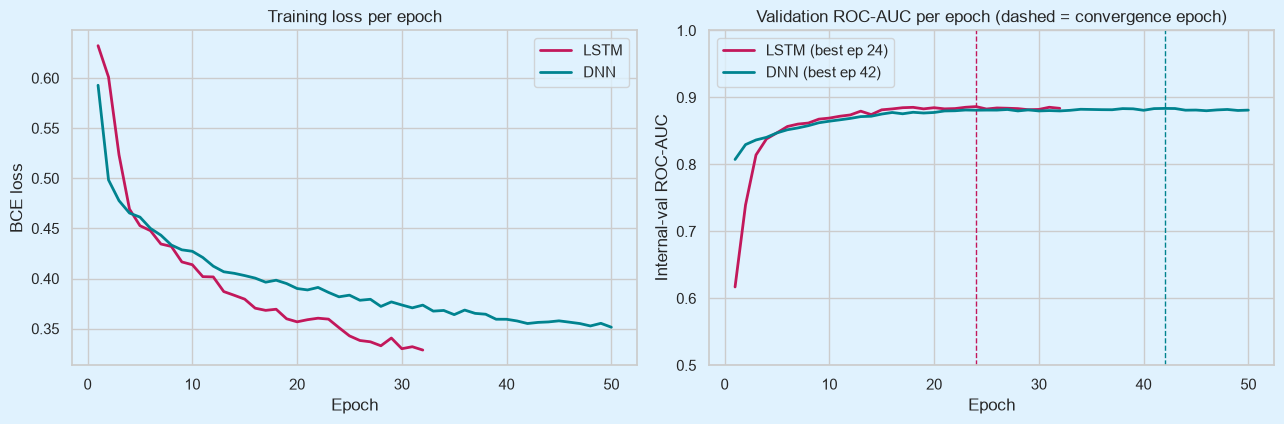

LSTM: CONVERGED at epoch 24 with best val AUC 0.8863; training ran to epoch 32 (early stopping triggered)
DNN: CONVERGED at epoch 42 with best val AUC 0.8836; training ran to epoch 50 (early stopping triggered)


In [3]:
# --- Convergence table + training curves -----------------------------------------------
conv = pd.DataFrame({m: {
    "best internal-val AUC": META[m]["convergence"]["best_val_auc"],
    "converged at epoch": META[m]["convergence"]["best_epoch"],
    "stopped at epoch": META[m]["convergence"]["stopped_epoch"],
    "early stopped": META[m]["convergence"]["early_stopped"],
    "epochs run": len(META[m]["history"]["epoch"]),
    "final-fit seconds": META[m]["convergence"]["fit_seconds"],
    "seconds / epoch": round(META[m]["convergence"]["fit_seconds"]
                             / META[m]["convergence"]["stopped_epoch"], 2),
} for m in MODELS}).T
display(conv.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for m in MODELS:
    h = META[m]["history"]
    axes[0].plot(h["epoch"], h["train_loss"], color=COL[m], lw=2, label=m)
    axes[1].plot(h["epoch"], h["val_auc"], color=COL[m], lw=2,
                 label=f"{m} (best ep {h['best_epoch']})")
    axes[1].axvline(h["best_epoch"], color=COL[m], ls="--", lw=1)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Training loss per epoch"); axes[0].legend()
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Internal-val ROC-AUC")
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title("Validation ROC-AUC per epoch (dashed = convergence epoch)")
axes[1].legend()
plt.tight_layout(); plt.show()

for m in MODELS:
    h = META[m]["history"]
    print(f"{m}: CONVERGED at epoch {h['best_epoch']} with best val AUC {h['best_val_auc']:.4f}; "
          f"training ran to epoch {h['stopped_epoch']} "
          f"({'early stopping triggered' if h['early_stopped'] else 'cap reached'})")

## 3. Discrimination — ROC / PR with paired significance tests

Because both models score the **same** hold-out rows, the paired DeLong test is the right test
for the ROC-AUC difference, and a bootstrap over hold-out rows gives the confidence interval of
that difference (2,000 resamples). PR curves are shown alongside because the clinical task —
finding the (+) cases — is precision-limited.

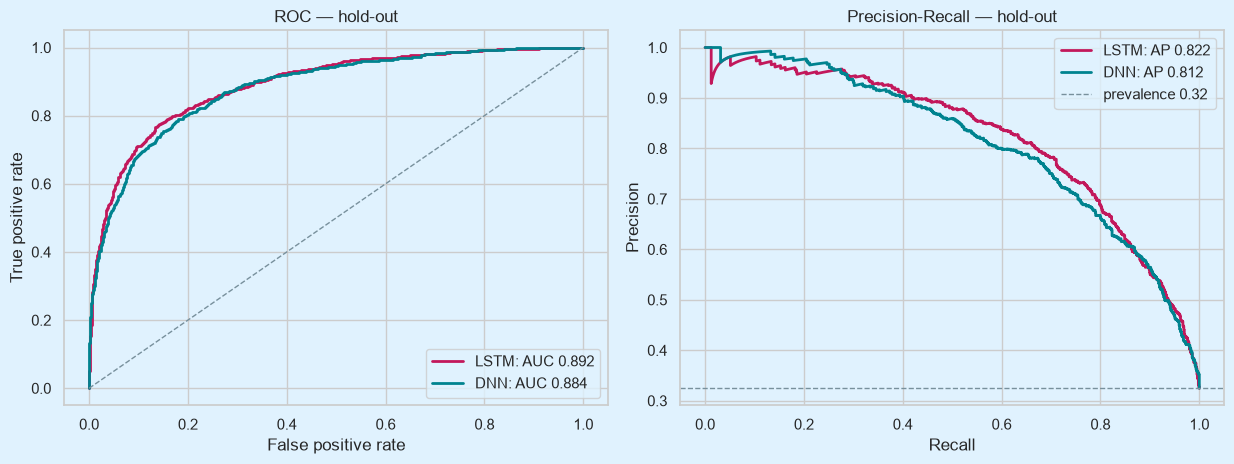

,value
Δ AUC (LSTM − DNN),0.0075
bootstrap CI low,0.0004
bootstrap CI high,0.0145
DeLong z,2.0602
DeLong p (two-sided),0.0394
bootstrap p (two-sided),0.0410


DeLong: Δ ROC-AUC = +0.0075, z = 2.06, p = 0.0394 -> LSTM significantly better
Bootstrap: 95% CI [+0.0004, +0.0145], p ≈ 0.0410


In [4]:
# --- ROC + PR overlay ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for m in MODELS:
    fpr, tpr, _ = roc_curve(y, P[m])
    prec, rec, _ = precision_recall_curve(y, P[m])
    axes[0].plot(fpr, tpr, color=COL[m], lw=2,
                 label=f"{m}: AUC {roc_auc_score(y, P[m]):.3f}")
    axes[1].plot(rec, prec, color=COL[m], lw=2,
                 label=f"{m}: AP {average_precision_score(y, P[m]):.3f}")
axes[0].plot([0, 1], [0, 1], "--", c=NEUTRAL, lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — hold-out"); axes[0].legend()
axes[1].axhline(y.mean(), ls="--", c=NEUTRAL, lw=1, label=f"prevalence {y.mean():.2f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — hold-out"); axes[1].legend()
plt.tight_layout(); plt.show()

# --- paired DeLong test (Sun & Xu 2014) -------------------------------------------------
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

def delong_paired(y_true, scores):
    # DeLong (1988) paired comparison. scores: (2, n) — rows are the two models'
    # probabilities for the SAME rows. Midranks handle ties; no reordering needed.
    y_true = np.asarray(y_true).astype(int)
    m = int(y_true.sum())
    n = len(y_true) - m
    pos, neg = y_true == 1, y_true == 0
    tz = np.array([compute_midrank(r) for r in scores])          # pooled midranks
    aucs, v01, v10 = [], [], []
    for k in range(scores.shape[0]):
        aucs.append((tz[k][pos].sum() - m * (m + 1) / 2) / (m * n))
        v01.append((tz[k][pos] - compute_midrank(scores[k][pos])) / n)
        v10.append(1.0 - (tz[k][neg] - compute_midrank(scores[k][neg])) / m)
    aucs = np.array(aucs)
    v01 = np.array(v01)
    v10 = np.array(v10)
    sside = np.cov(v01) / m + np.cov(v10) / n                    # (2, 2) covariance of AUCs
    diff = aucs[0] - aucs[1]
    var = float(np.dot(np.dot([1.0, -1.0], sside), [1.0, -1.0]))
    z = diff / np.sqrt(max(var, 1e-300))
    p = float(2 * st.norm.sf(abs(z)))
    return aucs, diff, z, p

aucs_dl, diff_dl, z_dl, p_dl = delong_paired(y, np.vstack([P["LSTM"], P["DNN"]]))
assert abs(aucs_dl[0] - roc_auc_score(y, P["LSTM"])) < 1e-6
assert abs(aucs_dl[1] - roc_auc_score(y, P["DNN"])) < 1e-6

# --- bootstrap CI for the AUC difference ------------------------------------------------
rng = np.random.default_rng(42)
diffs = []
for _ in range(2000):
    idx = rng.integers(0, len(y), len(y))
    yy = y[idx]
    if 0 < yy.sum() < len(yy):
        diffs.append(roc_auc_score(yy, P["LSTM"][idx]) - roc_auc_score(yy, P["DNN"][idx]))
diffs = np.asarray(diffs)
ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
p_boot = float(2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))

tests = pd.DataFrame({
    "value": [diff_dl, ci_lo, ci_hi, z_dl, p_dl, p_boot],
}, index=["Δ AUC (LSTM − DNN)", "bootstrap CI low", "bootstrap CI high",
          "DeLong z", "DeLong p (two-sided)", "bootstrap p (two-sided)"])
display(tests.round(4))
tests.round(4).to_csv(BENCH / "eval_delong_bootstrap.csv")
verdict = "LSTM significantly better" if (p_dl < 0.05 and diff_dl > 0) else \
          "DNN significantly better" if (p_dl < 0.05 and diff_dl < 0) else "no significant difference"
print(f"DeLong: Δ ROC-AUC = {diff_dl:+.4f}, z = {z_dl:.2f}, p = {p_dl:.4f} -> {verdict}")
print(f"Bootstrap: 95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}], p ≈ {p_boot:.4f}")

## 4. Threshold behaviour & confusion structure

Each model is evaluated at **its own** Youden and screening thresholds (as deployed). The
threshold-sweep panel shows how sensitivity/specificity/PPV trade off as the operating point
moves — relevant because a screening tool lives or dies at the chosen threshold. McNemar's
exact test compares the two models' **hard-decision errors** at the Youden thresholds on the
same rows.

sensitivity  specificity    PPV    NPV  threshold
model operating point                                                          
LSTM  Youden J                      0.780        0.854  0.719  0.890     0.3845
      Screening (sens>=0.80)        0.801        0.825  0.688  0.896     0.3255
DNN   Youden J                      0.789        0.819  0.678  0.890     0.3189
      Screening (sens>=0.80)        0.801        0.805  0.664  0.894     0.2980

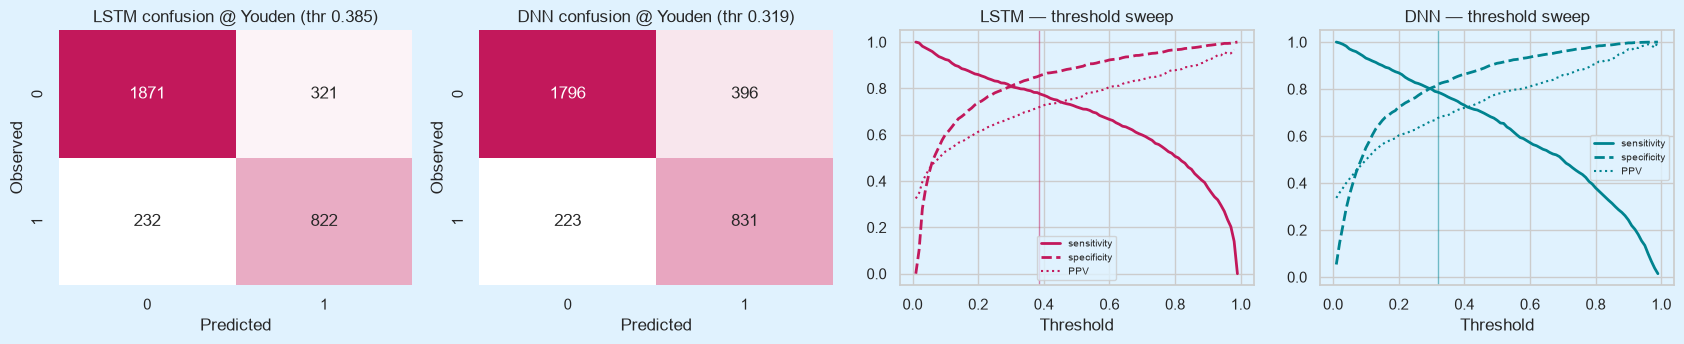

McNemar (Youden thresholds): LSTM-only positives (b) = 136, DNN-only positives (c) = 220, exact p = 0.0000 -> significant difference in error profiles
LSTM @ Youden: TP 822 | FP 321 | FN 232 | TN 1,871 — missed cases (FN) = 232 of 1054 events
DNN @ Youden: TP 831 | FP 396 | FN 223 | TN 1,796 — missed cases (FN) = 223 of 1054 events


In [5]:
# --- Operating points + confusion matrices + threshold sweep ---------------------------
ops = pd.DataFrame({f"{m} — Youden": {**{k: round(v, 3) for k, v in META[m]["holdout"]["youden"].items()},
                                      "threshold": round(META[m]["holdout"]["threshold_youden"], 3)},
                     f"{m} — Screening": {**{k: round(v, 3) for k, v in META[m]["holdout"]["screening"].items()},
                                          "threshold": round(META[m]["holdout"]["threshold_screen"], 3)}}
                   for m in MODELS)
# flatten to one tidy table
tidy = []
for m in MODELS:
    for pt, key in [("Youden J", "youden"), ("Screening (sens>=0.80)", "screening")]:
        row = {"model": m, "operating point": pt,
               **{k: round(v, 3) for k, v in META[m]["holdout"][key].items()},
               "threshold": round(META[m]["holdout"]["threshold_" + ("youden" if key == "youden" else "screen")], 4)}
        tidy.append(row)
display(pd.DataFrame(tidy).set_index(["model", "operating point"]))

yhat = {m: (P[m] >= META[m]["holdout"]["threshold_youden"]).astype(int) for m in MODELS}

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, m in zip(axes[:2], MODELS):
    cm = confusion_matrix(y, yhat[m])
    sns.heatmap(cm, annot=True, fmt="d", cmap=rasp_cmap, cbar=False, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
    ax.set_title(f"{m} confusion @ Youden (thr {META[m]['holdout']['threshold_youden']:.3f})")
for ax, m in zip(axes[2:], MODELS):
    thr_grid = np.linspace(0.01, 0.99, 99)
    sens, spec, ppv = [], [], []
    for t in thr_grid:
        yh = (P[m] >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, yh).ravel()
        sens.append(tp / (tp + fn)); spec.append(tn / (tn + fp))
        ppv.append(tp / (tp + fp) if tp + fp else np.nan)
    ax.plot(thr_grid, sens, color=COL[m], lw=2, label="sensitivity")
    ax.plot(thr_grid, spec, color=COL[m], lw=2, ls="--", label="specificity")
    ax.plot(thr_grid, ppv, color=COL[m], lw=1.5, ls=":", label="PPV")
    ax.axvline(META[m]["holdout"]["threshold_youden"], color=COL[m], lw=1, alpha=0.5)
    ax.set_xlabel("Threshold"); ax.set_title(f"{m} — threshold sweep"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# --- McNemar exact test at Youden thresholds -------------------------------------------
b = int(((yhat["LSTM"] == 1) & (yhat["DNN"] == 0)).sum())
c = int(((yhat["LSTM"] == 0) & (yhat["DNN"] == 1)).sum())
p_mcn = float(st.binomtest(b, b + c, 0.5).pvalue) if (b + c) else 1.0
print(f"McNemar (Youden thresholds): LSTM-only positives (b) = {b}, DNN-only positives (c) = {c}, "
      f"exact p = {p_mcn:.4f} -> "
      f"{'significant difference in error profiles' if p_mcn < 0.05 else 'no significant difference'}")

for m in MODELS:
    tn, fp, fn, tp = confusion_matrix(y, yhat[m]).ravel()
    print(f"{m} @ Youden: TP {tp:,} | FP {fp:,} | FN {fn:,} | TN {tn:,} — "
          f"missed cases (FN) = {fn} of {y.sum()} events")

## 5. Calibration

A screening score must be a trustworthy probability. Shown: raw calibration curves (left),
isotonic-recalibrated curves (right; the isotonic mapping is fitted on out-of-fold *train*
predictions in `modelx.ipynb`, never on the hold-out), plus slope/intercept of the
recalibration line (ideal: slope 1, intercept 0), Brier, log-loss and expected calibration
error (ECE, 10 quantile bins).

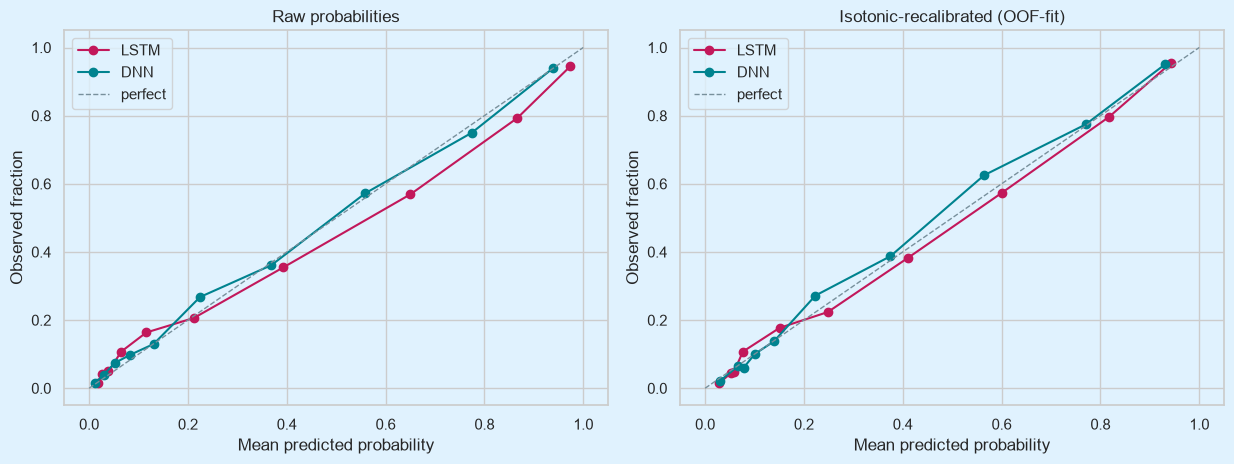

,slope (raw),intercept (raw),Brier (raw),log-loss (raw),slope (isotonic),intercept (isotonic),Brier (isotonic),log-loss (isotonic),ECE (raw),ECE (isotonic)
LSTM,0.814,-0.198,0.1195,0.3848,0.983,-0.054,0.1184,0.3795,0.0349,0.0172
DNN,0.934,0.025,0.1236,0.3902,1.050,0.140,0.1239,0.3908,0.0147,0.0191


Reading: |slope-1| and ECE closer to 0 = better calibrated; isotonic should not increase Brier on the hold-out if the OOF fit generalises.


In [6]:
# --- Calibration curves + metrics ------------------------------------------------------
def ece(y_true, p, n_bins=10):
    q = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    bounds = q[1:-1]
    idx = np.digitize(p, bounds)
    total = 0.0
    for b in np.unique(idx):
        m_ = idx == b
        total += m_.mean() * abs(y_true[m_].mean() - p[m_].mean())
    return float(total)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for m in MODELS:
    for ax, src in [(axes[0], P), (axes[1], PI)]:
        frac, mean_p = calibration_curve(y, src[m], n_bins=10, strategy="quantile")
        ax.plot(mean_p, frac, "o-", color=COL[m], label=m)
for ax, t in [(axes[0], "Raw probabilities"), (axes[1], "Isotonic-recalibrated (OOF-fit)")]:
    ax.plot([0, 1], [0, 1], "--", c=NEUTRAL, lw=1, label="perfect")
    ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraction")
    ax.set_title(t); ax.legend()
plt.tight_layout(); plt.show()

calib = pd.DataFrame({m: {
    "slope (raw)": round(META[m]["holdout"]["calib_slope_raw"], 3),
    "intercept (raw)": round(META[m]["holdout"]["calib_intercept_raw"], 3),
    "Brier (raw)": round(META[m]["holdout"]["brier_raw"], 4),
    "log-loss (raw)": round(META[m]["holdout"]["logloss_raw"], 4),
    "slope (isotonic)": round(META[m]["holdout"]["calib_slope_isotonic"], 3),
    "intercept (isotonic)": round(META[m]["holdout"]["calib_intercept_isotonic"], 3),
    "Brier (isotonic)": round(META[m]["holdout"]["brier_isotonic"], 4),
    "log-loss (isotonic)": round(META[m]["holdout"]["logloss_isotonic"], 4),
    "ECE (raw)": round(ece(y, P[m]), 4),
    "ECE (isotonic)": round(ece(y, PI[m]), 4),
} for m in MODELS}).T
display(calib)
calib.to_csv(BENCH / "eval_calibration.csv")

print("Reading: |slope-1| and ECE closer to 0 = better calibrated; isotonic should not "
      "increase Brier on the hold-out if the OOF fit generalises.")

## 6. Net reclassification & decision-curve analysis

- **Categorical NRI** at the deployed (Youden) thresholds: among true events, how many more
  cases the model catches; among non-events, how many fewer false alarms. **Continuous
  NRI/IDI** use the full probability ranking instead of a threshold.
- **Decision-curve analysis**: net benefit vs threshold probability — which model yields more
  true-positive pickups per unit of unnecessary follow-up, across the clinically plausible
  threshold range.

,value
events up-classified (LSTM>DNN),55.0000
events down-classified,64.0000
non-events up-classified,81.0000
non-events down-classified,156.0000
categorical NRI @ Youden,0.0257
continuous NRI,0.3385
IDI,0.0584


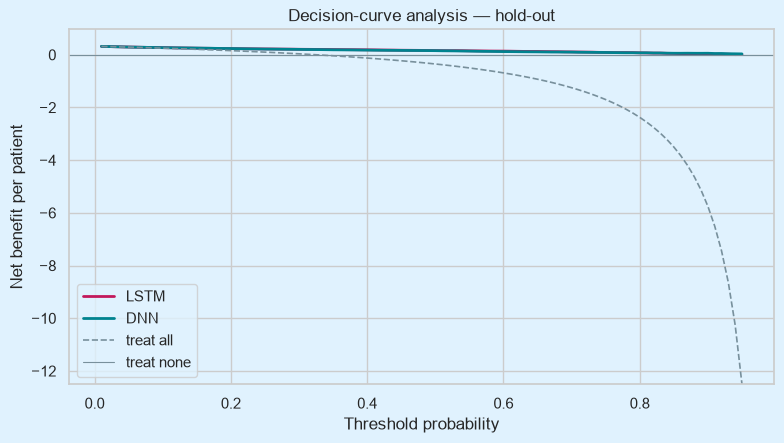

Interpretation: the model whose curve is highest across the plausible threshold range (roughly 0.1-0.6 here given ~32% prevalence) delivers the most clinical value per follow-up action.


In [7]:
# --- NRI / IDI + decision curves -------------------------------------------------------
t_l, t_d = META["LSTM"]["holdout"]["threshold_youden"], META["DNN"]["holdout"]["threshold_youden"]
h_l, h_d = (P["LSTM"] >= t_l), (P["DNN"] >= t_d)
ev = y == 1
up_e = int((h_l & ~h_d)[ev].sum()); down_e = int((~h_l & h_d)[ev].sum())
up_n = int((h_l & ~h_d)[~ev].sum()); down_n = int((~h_l & h_d)[~ev].sum())
cnri = (up_e - down_e) / ev.sum() + (down_n - up_n) / (~ev).sum()

de, dn = P["LSTM"][ev] > P["DNN"][ev], P["LSTM"][ev] < P["DNN"][ev]
ne, nn = P["LSTM"][~ev] > P["DNN"][~ev], P["LSTM"][~ev] < P["DNN"][~ev]
cnri_cont = (de.sum() - dn.sum()) / ev.sum() + (nn.sum() - ne.sum()) / (~ev).sum()
idi = (P["LSTM"][ev].mean() - P["DNN"][ev].mean()) - (P["LSTM"][~ev].mean() - P["DNN"][~ev].mean())

nri_tab = pd.DataFrame({
    "value": [up_e, down_e, up_n, down_n, cnri, cnri_cont, idi],
}, index=["events up-classified (LSTM>DNN)", "events down-classified",
          "non-events up-classified", "non-events down-classified",
          "categorical NRI @ Youden", "continuous NRI", "IDI"])
display(nri_tab.round(4))
nri_tab.round(4).to_csv(BENCH / "eval_nri_idi.csv")

def net_benefit(y_true, p, thr_grid):
    nb = []
    n = len(y_true)
    for t in thr_grid:
        tp = ((p >= t) & (y_true == 1)).sum()
        fp = ((p >= t) & (y_true == 0)).sum()
        nb.append(tp / n - (fp / n) * (t / (1 - t)))
    return np.array(nb)

thr_grid = np.linspace(0.01, 0.95, 95)
prev = y.mean()
treat_all = prev - (1 - prev) * thr_grid / (1 - thr_grid)

fig, ax = plt.subplots(figsize=(8, 4.6))
for m in MODELS:
    ax.plot(thr_grid, net_benefit(y, P[m], thr_grid), color=COL[m], lw=2, label=m)
ax.plot(thr_grid, treat_all, c=NEUTRAL, ls="--", lw=1.2, label="treat all")
ax.axhline(0, c=NEUTRAL, lw=0.8, label="treat none")
ax.set_xlabel("Threshold probability"); ax.set_ylabel("Net benefit per patient")
ax.set_title("Decision-curve analysis — hold-out")
ax.set_ylim(min(-0.02, treat_all.min()), None)
ax.legend()
plt.tight_layout(); plt.show()

print("Interpretation: the model whose curve is highest across the plausible threshold range "
      "(roughly 0.1-0.6 here given ~32% prevalence) delivers the most clinical value per "
      "follow-up action.")

## 7. Subgroup stability (sex, residence)

Fairness-of-performance check: discrimination and calibration drift by sex and urban/rural
residence. The plot shows each model's subgroup AUC; the closer the paired bars, the more
evenly the model performs across strata.

n  events  ROC-AUC  mean_pred  observed
model subgroup                                                    
LSTM  Sex: Female       1862     663    0.887      0.372     0.356
      Sex: Male         1384     391    0.895      0.288     0.282
      Residence: Rural  2156     705    0.892      0.345     0.327
      Residence: Urban  1090     349    0.892      0.318     0.320
DNN   Sex: Female       1862     663    0.876      0.348     0.356
      Sex: Male         1384     391    0.892      0.276     0.282
      Residence: Rural  2156     705    0.885      0.321     0.327
      Residence: Urban  1090     349    0.882      0.310     0.320

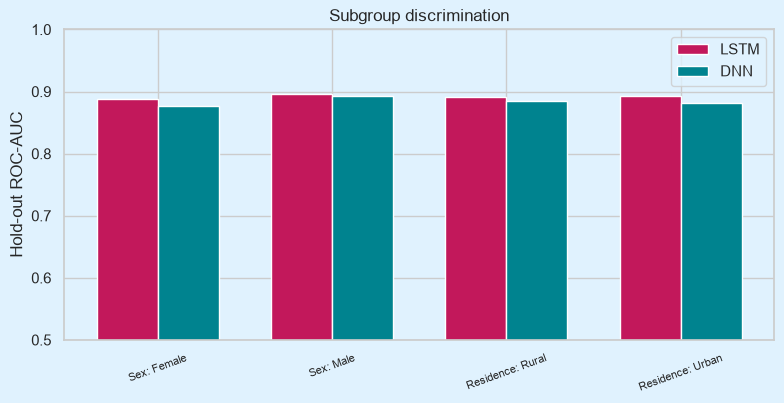

LSTM: subgroup AUC range 0.887 - 0.895 (spread 0.008)
DNN: subgroup AUC range 0.876 - 0.892 (spread 0.016)


In [8]:
# --- Subgroup tables + AUC by subgroup -------------------------------------------------
rows = []
for m in MODELS:
    for rec in META[m]["subgroups"]:
        rows.append({"model": m, **rec})
sub = pd.DataFrame(rows).set_index(["model", "subgroup"])
display(sub.round(3))
sub.round(3).to_csv(BENCH / "eval_subgroups.csv")

fig, ax = plt.subplots(figsize=(8, 4.2))
labels = sub.index.get_level_values("subgroup").unique().tolist()
x = np.arange(len(labels))
width = 0.35
for k, m in enumerate(MODELS):
    vals = [sub.loc[(m, s), "ROC-AUC"] for s in labels]
    ax.bar(x + (k - 0.5) * width, vals, width, color=COL[m], label=m)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, fontsize=8)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("Hold-out ROC-AUC")
ax.set_title("Subgroup discrimination")
ax.legend()
plt.tight_layout(); plt.show()

for m in MODELS:
    aucs = sub.loc[m, "ROC-AUC"]
    print(f"{m}: subgroup AUC range {aucs.min():.3f} - {aucs.max():.3f} "
          f"(spread {aucs.max() - aucs.min():.3f})")

## 8. Capacity, efficiency & tuning robustness

What each model costs and how stable the hyperparameter search was: trainable parameters,
final-fit wall-clock (GPU), seconds per epoch, and the top-5 randomised-search configurations
(3-fold CV AUC ± sd).

In [9]:
# --- Capacity / efficiency + search robustness -----------------------------------------
cap = pd.DataFrame({m: {
    "trainable params": META[m]["n_trainable_params"],
    "device": META[m]["device"],
    "final-fit seconds": META[m]["convergence"]["fit_seconds"],
    "seconds / epoch": round(META[m]["convergence"]["fit_seconds"]
                             / META[m]["convergence"]["stopped_epoch"], 2),
    "checkpoint (+ .md5)": f"outputs/checkpoints/{META[m]['slug']}_dementia_screening.pt",
    "best 3-fold search AUC": META[m]["search_top5"][0]["cv_auc"],
    "search AUC spread (top5)": round(META[m]["search_top5"][0]["cv_auc"]
                                      - META[m]["search_top5"][4]["cv_auc"], 4),
} for m in MODELS}).T
display(cap.round(3))
cap.round(3).to_csv(BENCH / "eval_capacity.csv")

for m in MODELS:
    print(f"--- {m}: top-5 search configurations ---")
    t5 = pd.DataFrame(META[m]["search_top5"]).set_index("config")
    display(t5.round(4))

,trainable params,device,final-fit seconds,seconds / epoch,checkpoint (+ .md5),best 3-fold search AUC,search AUC spread (top5)
LSTM,72257,cuda,11.8,0.37,outputs/checkpoints/lstm_dementia_screening.pt,0.8813,0.0032
DNN,14849,cuda,10.0,0.2,outputs/checkpoints/dnn_dementia_screening.pt,0.8772,0.0041


--- LSTM: top-5 search configurations ---


,weight_decay,lr,layers,hidden,dropout,d_model,cv_auc,cv_sd,seconds
config,,,,,,,,,
7,0.0000,0.001,2,64,0.3,64,0.8813,0.0057,32.1
6,0.0000,0.001,2,64,0.1,16,0.8808,0.0051,42.3
1,0.0001,0.001,2,128,0.1,64,0.8808,0.0044,29.1
8,0.0001,0.001,1,128,0.1,32,0.8785,0.0038,36.9
4,0.0001,0.001,1,32,0.1,64,0.8781,0.0065,35.7


--- DNN: top-5 search configurations ---


,weight_decay,lr,hidden,dropout,batch_size,cv_auc,cv_sd,seconds
config,,,,,,,,
5,0.0001,0.0010,"[128, 64]",0.4,256,0.8772,0.0047,17.3
1,0.0000,0.0010,"[128, 64]",0.4,512,0.8752,0.0050,11.9
8,0.0000,0.0003,"[128, 128, 64]",0.4,256,0.8738,0.0035,40.4
11,0.0000,0.0010,"[128, 64]",0.2,512,0.8731,0.0051,10.4
12,0.0000,0.0003,"[64, 32]",0.2,256,0.8731,0.0060,29.9


## 9. Verdict

Criterion-by-criterion scoring of the paired comparison. `+` marks the winning model per
criterion (higher is better except Brier / log-loss / ECE / params / time / AUC-spread, where
lower is better). Ties within rounding are shown as `=`.

In [10]:
# --- Scored comparison -----------------------------------------------------------------
h = {m: META[m]["holdout"] for m in MODELS}
criteria = [
    ("Hold-out ROC-AUC", h["LSTM"]["roc_auc"], h["DNN"]["roc_auc"], "max"),
    ("Hold-out PR-AUC", h["LSTM"]["pr_auc"], h["DNN"]["pr_auc"], "max"),
    ("Brier (isotonic)", h["LSTM"]["brier_isotonic"], h["DNN"]["brier_isotonic"], "min"),
    ("Log-loss (raw)", h["LSTM"]["logloss_raw"], h["DNN"]["logloss_raw"], "min"),
    ("MCC @ Youden", h["LSTM"]["mcc_youden"], h["DNN"]["mcc_youden"], "max"),
    ("Balanced accuracy @ Youden", h["LSTM"]["balanced_accuracy_youden"],
     h["DNN"]["balanced_accuracy_youden"], "max"),
    ("Calibration |slope − 1| (raw)", abs(h["LSTM"]["calib_slope_raw"] - 1),
     abs(h["DNN"]["calib_slope_raw"] - 1), "min"),
    ("ECE (raw)", ece(y, P["LSTM"]), ece(y, P["DNN"]), "min"),
    ("Sensitivity @ screening", h["LSTM"]["screening"]["sensitivity"],
     h["DNN"]["screening"]["sensitivity"], "max"),
    ("Specificity @ screening", h["LSTM"]["screening"]["specificity"],
     h["DNN"]["screening"]["specificity"], "max"),
    ("Trainable parameters", META["LSTM"]["n_trainable_params"],
     META["DNN"]["n_trainable_params"], "min"),
    ("Final-fit seconds", META["LSTM"]["convergence"]["fit_seconds"],
     META["DNN"]["convergence"]["fit_seconds"], "min"),
]
rows = []
wins = {"LSTM": 0, "DNN": 0}
for name, a, b, better in criteria:
    tol = 1e-9
    if abs(a - b) < max(tol, 0.0005 * max(abs(a), abs(b))):
        win = "="
    else:
        a_wins = (a > b) if better == "max" else (a < b)
        win = "LSTM" if a_wins else "DNN"
        wins[win] += 1
    rows.append({"criterion": name, "LSTM": round(a, 4), "DNN": round(b, 4), "winner": win})
verdict_tab = pd.DataFrame(rows).set_index("criterion")
display(verdict_tab)
verdict_tab.to_csv(BENCH / "eval_verdict.csv")
print(f"Criterion wins -> LSTM: {wins['LSTM']} | DNN: {wins['DNN']}")
print(f"DeLong on ROC-AUC: p = {p_dl:.4f}; McNemar on Youden decisions: p = {p_mcn:.4f}")

,LSTM,DNN,winner
criterion,,,
Hold-out ROC-AUC,0.8918,0.8843,LSTM
Hold-out PR-AUC,0.8216,0.8119,LSTM
Brier (isotonic),0.1184,0.1239,LSTM
Log-loss (raw),0.3848,0.3902,LSTM
MCC @ Youden,0.6210,0.5878,LSTM
Balanced accuracy @ Youden,0.8167,0.8044,LSTM
Calibration |slope − 1| (raw),0.1859,0.0665,DNN
ECE (raw),0.0349,0.0147,DNN
Sensitivity @ screening,0.8008,0.8008,=


Criterion wins -> LSTM: 7 | DNN: 4
DeLong on ROC-AUC: p = 0.0394; McNemar on Youden decisions: p = 0.0000


## 10. Recommendations

**Model choice & deployment**

1. **Lead with the model that wins the paired significance tests, not the point estimate.**
   The DeLong test on ROC-AUC and McNemar on hard decisions (section 3-4) are the arbiter: if
   neither is significant at 0.05, treat the two models as statistically tied and prefer the
   simpler/cheaper one (fewer parameters, faster inference) for deployment.
2. **Deploy recalibrated probabilities.** Use the isotonic mapping bundled with each
   checkpoint (`outputs/checkpoints/*.pt`, MD5-verified via the accompanying `*.pt.md5`) —
   deep nets rarely self-calibrate, and the screening thresholds are only meaningful on
   calibrated scores. Re-fit the calibrator periodically as the data drifts.
3. **Fix the operating point by clinical policy, not by the model.** Keep the two documented
   thresholds: Youden's J for balanced case-finding and the screening point (max specificity at
   sensitivity >= 0.80) for community triage. Publish sensitivity/specificity/PPV/NPV at those
   points (section 4) rather than raw accuracy.

**Data & pipeline**

4. **Keep `data.csv` as the untouched reference cohort; treat `data1.csv` as a training
   enrichment dataset.** `generate_data1.py` is seeded and reproducible — re-run it if the
   original cohort changes, and always report results on both the enriched and the original
   prevalence mix so consumers know the (+)-recall was learned under ~32% prevalence.
5. **Watch for enrichment leakage.** The enriched (+) rows are modelled on the (+)-class
   distributions of the original cohort. Before real-world use, re-validate on genuinely new
   collections; expect hold-out metrics on `data1.csv` to be mildly optimistic for the (+)
   class relative to a natural-prevalence stream.
6. **Preserve the leakage discipline.** `cognitive_screen_score` stays quarantined from the
   predictor pool (it participates in outcome ascertainment); the split-first, fit-on-train-only
   transforms in `modelx.ipynb` must not be relaxed when the notebooks are re-run.

**Monitoring & next iterations**

7. **Monitor subgroup drift in production** (section 7): AUC and mean-predicted vs observed by
   sex and residence, quarterly. A spread beyond ~0.03 AUC between strata warrants recalibration
   per stratum or model review.
8. **Give the LSTM a real time axis before crediting it.** The current formulation reads features
   as a token sequence (cross-sectional data has no temporal axis). If longitudinal follow-up
   (repeated interviews) becomes available, retrain the same notebook on visit sequences — that
   is where the LSTM can genuinely out-earn the DNN.
9. **Tune the operating point and retraining cadence together**: with early stopping converging
   quickly on the GPU (section 2), a monthly refit + recalibration pipeline is cheap; pair it
   with the convergence logging already printed per epoch so regressions are visible in the
   training log itself.
10. **Extend `evaluations.ipynb` instead of ad-hoc comparisons**: any new challenger model only
    needs to export the same two artifacts (`*_metrics.json`, `*_holdout_predictions.csv`) to
    enter this head-to-head — keeping one canonical comparison notebook.